Analiza danych za pomocą biblioteki pandas

In [2]:
import pandas as pd 
import scipy 
import datetime
import pandas_datareader.data as web
import numpy as np    

Dane finansowe pozyskiwane ze strony stooq.pl

In [3]:
df = web.DataReader('kgh.pl', 'stooq')
df = df[:365] # ilość ostatnich dni 

Movie average

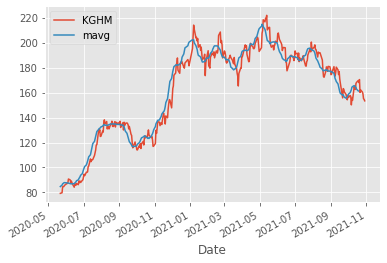

In [6]:
cena_close = df["Close"]
srednia_kroczaca = cena_close.rolling(window=10).mean()
df['srednia'] = df['Close'].ewm(span=10, adjust=False).mean()

import matplotlib.pyplot as plt 
from matplotlib import style

style.use("ggplot")

cena_close.plot(label = "KGHM")
srednia_kroczaca.plot(label = "mavg")
plt.legend()

Log returns

Text(0.5, 1.0, 'KGHM volatility: 41.81%')

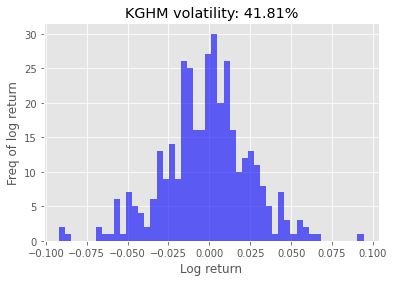

In [7]:
df['Log returns'] = np.log(df['Close']/df['Close'].shift())
df['Log returns'].std()
volatility = df['Log returns'].std()*252**.5

str_vol = str(round(volatility, 4)*100)

fig, ax = plt.subplots()
df['Log returns'].hist(ax=ax, bins=50, alpha=0.6, color='b')
ax.set_xlabel("Log return")
ax.set_ylabel("Freq of log return")
ax.set_title("KGHM volatility: " + str_vol + "%")

MACD 

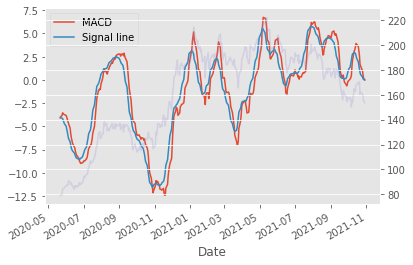

In [8]:
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp1 - exp2
df['Signal line'] = df['MACD'].ewm(span=9, adjust=False).mean()

fig, ax = plt.subplots()
df[['MACD', 'Signal line']].plot(ax=ax)
df['Close'].plot(ax=ax, alpha=0.25, secondary_y=True)

http://www.learnpythonwithrune.org/wp-content/uploads/2021/03/Skaermbillede-2021-03-01-kl.-13.54.42.png

Text(0.5, 1.0, 'Return')

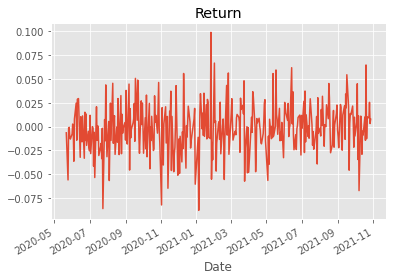

In [11]:
rets = cena_close/cena_close.shift(1) - 1

rets.plot(label = "return")
plt.title("Return")

Analiza konkurencji 

In [14]:
dfcomp = web.DataReader(["kgh.pl", "zue.pl", "pzu.pl", "pkn.pl", "peo.pl"], "stooq")["Close"]
dfcomp

Symbols,kgh.pl,zue.pl,pzu.pl,pkn.pl,peo.pl
Date,,,,,
2016-11-02,67.819,8.91,20.974,63.859,92.282
2016-11-03,68.291,8.90,21.168,64.325,92.683
2016-11-04,69.528,8.55,21.176,61.946,92.328
2016-11-07,71.209,8.20,21.191,62.149,93.067
2016-11-08,73.666,8.40,21.285,62.750,94.416
...,...,...,...,...,...
2021-10-25,160.500,3.58,39.380,89.540,124.000
2021-10-26,159.050,3.56,40.240,89.500,125.550
2021-10-27,155.100,3.70,39.520,89.100,125.350


Analiza korelacji 

Text(0, 0.5, 'Zwrot PZU SA')

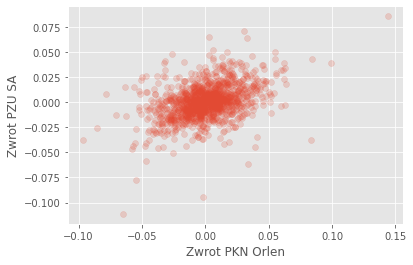

In [15]:
retscomp = dfcomp.pct_change()
corr = retscomp.corr()
corr

plt.scatter(retscomp["pkn.pl"], retscomp["pzu.pl"], alpha = 0.2)
plt.xlabel('Zwrot PKN Orlen') 
plt.ylabel('Zwrot PZU SA')

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fd39c97cf90>,
      dtype=object)

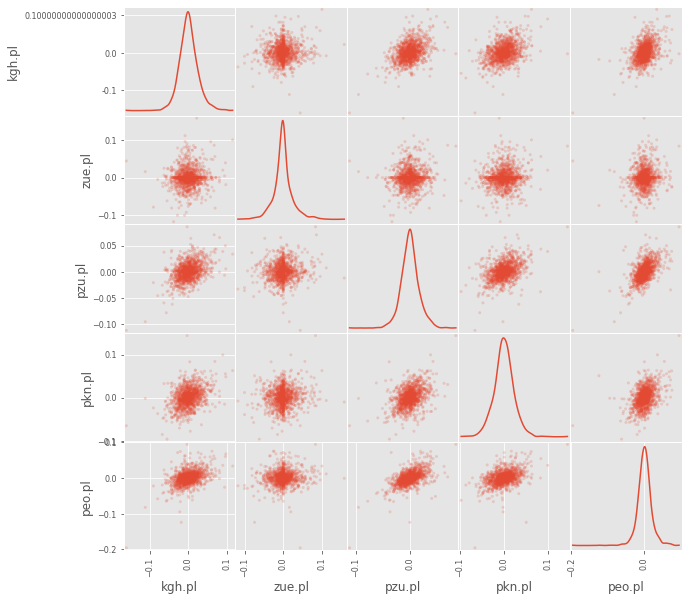

In [16]:
pd.plotting.scatter_matrix(retscomp, diagonal='kde', figsize=(10, 10), alpha = 0.2)


Text(0.5, 1.0, 'Heatmap')

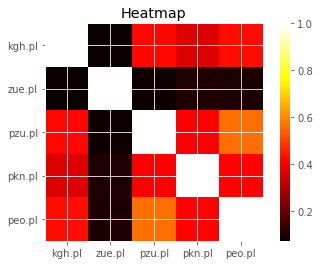

In [17]:
plt.imshow(corr, cmap='hot', interpolation='none') 
plt.colorbar() 
plt.xticks(range(len(corr)), corr.columns) 
plt.yticks(range(len(corr)) , corr.columns)
plt.title("Heatmap")

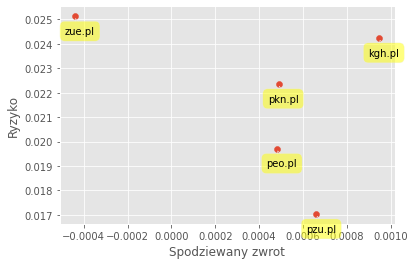

In [22]:
plt.scatter(retscomp.mean(), retscomp.std())
plt.xlabel('Spodziewany zwrot')
plt.ylabel('Ryzyko')
for label, x, y in zip(retscomp.columns, retscomp.mean(), retscomp.std()):
    plt.annotate(
        label, 
        xy = (x, y), xytext = (20, -20),
        textcoords = 'offset points', ha = 'right', va = 'bottom',
        bbox = dict(boxstyle = 'round,pad=0.5', fc = 'yellow', alpha = 0.5),
        arrowprops = dict(arrowstyle = '->', connectionstyle = 'arc3,rad=0'))

Simple Linear Analysis, Quadratic Discriminant Analysis (QDA), and K Nearest Neighbor (KNN).

In [23]:
dfreg = df.loc[:,[‘Close’,’Volume’]]
dfreg[‘HL_PCT’] = (df[‘High’] — df[‘Low’]) / df[‘Close’] * 100.0
dfreg[‘PCT_change’] = (df[‘Close’] — df[‘Open’]) / df[‘Open’] * 100.0

SyntaxError: ignored

In [ ]:
# Drop missing value
dfreg.fillna(value=-99999, inplace=True)
# We want to separate 1 percent of the data to forecast
forecast_out = int(math.ceil(0.01 * len(dfreg)))
# Separating the label here, we want to predict the AdjClose
forecast_col = 'Adj Close'
dfreg['label'] = dfreg[forecast_col].shift(-forecast_out)
X = np.array(dfreg.drop(['label'], 1))
# Scale the X so that everyone can have the same distribution for linear regression
X = preprocessing.scale(X)
# Finally We want to find Data Series of late X and early X (train) for model generation and evaluation
X_lately = X[-forecast_out:]
X = X[:-forecast_out]
# Separate label and identify it as y
y = np.array(dfreg['label'])
y = y[:-forecast_out]

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [ ]:
# Linear regression
clfreg = LinearRegression(n_jobs=-1)
clfreg.fit(X_train, y_train)
# Quadratic Regression 2
clfpoly2 = make_pipeline(PolynomialFeatures(2), Ridge())
clfpoly2.fit(X_train, y_train)

# Quadratic Regression 3
clfpoly3 = make_pipeline(PolynomialFeatures(3), Ridge())
clfpoly3.fit(X_train, y_train)

In [ ]:
# Linear regression
clfreg = LinearRegression(n_jobs=-1)
clfreg.fit(X_train, y_train)
# Quadratic Regression 2
clfpoly2 = make_pipeline(PolynomialFeatures(2), Ridge())
clfpoly2.fit(X_train, y_train)

# Quadratic Regression 3
clfpoly3 = make_pipeline(PolynomialFeatures(3), Ridge())
clfpoly3.fit(X_train, y_train)

In [ ]:
confidencereg = clfreg.score(X_test, y_test)
confidencepoly2 = clfpoly2.score(X_test,y_test)
confidencepoly3 = clfpoly3.score(X_test,y_test)
confidenceknn = clfknn.score(X_test, y_test)
# results
('The linear regression confidence is ', 0.96399641826551985)
('The quadratic regression 2 confidence is ', 0.96492624557970319)
('The quadratic regression 3 confidence is ', 0.9652082834532858)
('The knn regression confidence is ', 0.92844658034790639)

In [ ]:
last_date = dfreg.iloc[-1].name
last_unix = last_date
next_unix = last_unix + datetime.timedelta(days=1)

for i in forecast_set:
    next_date = next_unix
    next_unix += datetime.timedelta(days=1)
    dfreg.loc[next_date] = [np.nan for _ in range(len(dfreg.columns)-1)]+[i]
dfreg['Adj Close'].tail(500).plot()
dfreg['Forecast'].tail(500).plot()
plt.legend(loc=4)
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [ ]:
dane = pd.read_csv("/content/drive/MyDrive/Wykład_pandas (Odpowiedzi) - Liczba odpowiedzi_ 1 (2).csv")
dane.head()


,Czas,plec,szkola,woj,matura,data,chemia
0,2021-10-31 21:57:10,Mężczyzna,Liceum,Lubelskie,54,2021-10-07,Nie
1,2021-10-31 21:57:24,Kobieta,Technikum,Opolskie,65,2021-10-15,Tak
2,2021-10-31 21:57:42,Osoba niebinarna,Szkoła zawodowa,Łódzkie,99,2021-10-03,Nie
3,2021-11-01 06:35:11,Kobieta,Szkoła zawodowa,Lubuskie,42,2021-11-18,Tak
4,2021-11-01 06:35:32,Mężczyzna,Liceum,Małopolskiego,12,2021-11-28,Tak


In [ ]:
pl = dane[["plec", "matura"]]

pl2 = dane[["szkola ", "matura"]]

grouped = pl.pivot(columns = "plec", values = "matura")

dd = dane[["szkola ", "matura"]]

grouped2 = pl2.pivot(columns = "szkola ", values="matura")

nowe = grouped.merge(grouped2) 

MergeError: ignored

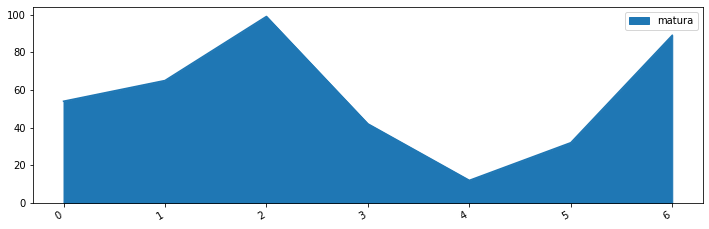

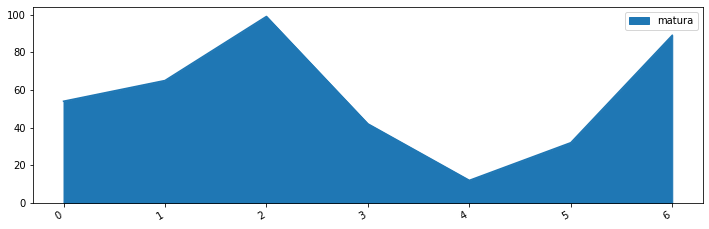

In [118]:
axs = pl2.plot.area(figsize=(12, 4), subplots=True)
ax1 = pl2.plot.area(figsize=(12, 4), subplots=True)